0<div class = "alert alert-block alert-info"> 
    
# LA PROGRAMMATION ORIENTEE OBJET  
    
    
## Notion de paradigme  

En informatique, on parle de paradigme pour caractériser le modèle sous-jacent à un langage. Il existe de nombreux types de paradigme : impératif, logique, fonctionnel, objet, réactif, … 

Langages  mono-paradigmes : 
- C : impératif, 
- Haskell : fonctionnel
- Prolog : logique. 

Beaucoup de langages autorisent plusieurs paradigmes, même si un prédomine : 
- Caml est essentiellement fonctionnel, même s’il possède des structures impératives ; 
- Java et python sont un langages impératifs et objet, mais il propose des aspects fonctionnels.    
    
### Le paradigme impératif  
    
- **langage impératif** : séquence d’instructions.
- **instruction** : ordre donné à l’ordinateur.
- **variable** : stocke une valeur.
- **affectation** : associe une information à une variable. La notion d’affectation est une notion que l’on trouve dans tous les langages impératifs. Le symbole peut varier d’un langage à l’autre (signe « = » en Python, Java ou C par exemple, signe «:= » en Pascal,etc.).
- **état d’un programme** : ensemble de la valeur de ses variables à un instant donné.
  
#### Conception procédurale du code
    
- Division en sous-programme : **fonctions** et **procédures**;  
- traitement hiérarsé;
- approche orientée **traitement** : **Que dois faire le programme ?**   

    
#### Limites
    
Le paradigme de programmation impératif consiste à donner des instructions les unes à la suite des autres.  
    
Si ce paradigme marche très bien pour les petits scripts, il devient inapproprié pour des codebases plus conséquentes. 
    
Son architecture globale devient :

- Une série de fonctions prenant de nombreux arguments :
    - fonction_1
    - fonction_2
    - ...
    - fonction_999
- des procédures :    
    - procedure_1
    - ...
    - procedure_99
- et quantité de variables, plus ou moins globales
    - variable_1
    - ...
    - variable_999

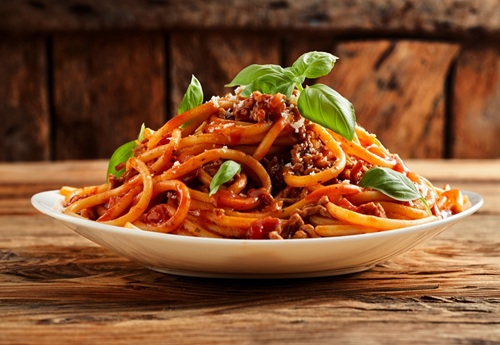 
    
Ce ressemble de plus en plus a un gigantesque plat de spaghetti indémêlable qui présente les limites suivantes :    
- toutes les variables sont stockées dans un seul espace de nommage;  
- on a le choix entre les déclarer en global ou multiplier le nombre de paramêtre par fonctions;    
- Le code produit n’est pas réutilisable sans réécrire le code source intégralement;
- le lien entre les traitements et les variables concernées devient flous et peu lisible;    
- tout étant plus ou moins imbriqué, cela ne facilite pas le travail a plusieurs ...    
   

<div class = "alert alert-block alert-info"> 
    
## Approche orientée objet 

### Conception orientée objet
    
- On modélise les données comme des objets;  
- Données et traitement sont encapsulés ensembles;
- approche orientée **données** : **Sur quoi porte le programme ?**    
    

### Comparaison Procédural vs Objet

Un extrait du jeu du pendu    
    
Approche ***traitement*** :  
    
```python
def ajoute_lettre(lettre: str, mot_solution: list, mot_incomplet: list) -> None:
    for i in range(len(mot_solution)):
        if lettre == mot_solution[i]:
            mot_incomplet[i] = lettre

def test_lettre(lettre: str, mot_solution: list) -> bool:
    return lettre in mot_solution

def test_mot_trouve(lst_mot: list) -> bool:
    return not '_' in lst_mot

mot_mystere = list('INFORMATIQUE')
mot_du_joueur = ['_'] * len(mot_mystere)

i = 0
while not test_mot_trouve(mot_du_joueur):
    if test_lettre(chr(65 + i), mot_mystere):
        ajoute_lettre(chr(65 + i), mot_mystere, mot_du_joueur)
        print(' '.join(mot_du_joueur))
    i += 1    
    
```    
    
Approche ***donnée*** :  
    
```python
class MotMystere:
    def __init__(self, m: str):
        self._mot_mystere = list(m.upper())
        self._mot_du_joueur = ['_'] * len(self._mot_mystere)
    
    def ajoute_lettre(self, lettre: str) -> None:
        for i in range(len(self._mot_mystere)):
            if lettre == self._mot_mystere[i]:
                self._mot_du_joueur[i] = lettre

    def test_lettre(self, lettre: str) -> bool:
        return lettre in self._mot_mystere

    def est_trouve(self) -> bool:
        return not '_' in self._mot_du_joueur
    
    def __repr__(self) -> str:
        return ' '.join(self._mot_du_joueur)
    
mot = MotMystere('informatique')

i = 0
while not mot.est_trouve():
    if mot.test_lettre(chr(65 + i)):
        mot.ajoute_lettre(chr(65 + i))
        print(mot)
    i += 1   
    
```     
    
Dans les deux cas, le résultat est :
    
```python
_ _ _ _ _ _ A _ _ _ _ _
_ _ _ _ _ _ A _ _ _ _ E
_ _ F _ _ _ A _ _ _ _ E
I _ F _ _ _ A _ I _ _ E
I _ F _ _ M A _ I _ _ E
I N F _ _ M A _ I _ _ E
I N F O _ M A _ I _ _ E
I N F O _ M A _ I Q _ E
I N F O R M A _ I Q _ E
I N F O R M A T I Q _ E
I N F O R M A T I Q U E
```    
    
### Les 4 piliers de la programmation objet    
    
La POO repose sur quatre principes fondamentaux que nous allons dévelloper dans la suite :  
    
- **l'encapsulation :** permet de lier les données aux programmes qui les manipule dans un espace commun.
- **l'abstraction :** consiste à afficher ou masquer les détails d’un objet à l’utilisateur (ou aux autres objets avec lequel il interagit) pour n’exposer que les éléments qui leur seront utiles.
- **le polymorphisme :** permet de créer des fonctions qui soient compatibles avec des objets de nature différents.
- **l'héritage :** permet à un objet d’acquérir les propriétés d’un autre objet.   
    
### Encapsulation  
    
La poo permet de modéliser son code sous forme d’objets **contenant les données et leurs traitements** et qui interagissent entre eux plutôt qu’une séquence d’instructions.
    
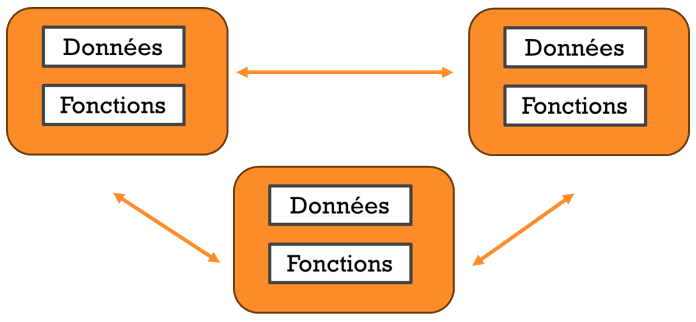    
    
Le premier bénéfice réside dans le fait que les différents objets utilisés peuvent être construits indépendamment les uns des autres (par exemple par des programmeurs différents) sans qu’il n’y ait de risque d’interférence.

#### Les attributs  
    
Ce sont les données encapsulées dans l'objet et qui caractérise l'état de l'objet.  
    
#### Les méthodes  
    
Ce sont les traitements que l'objet peut s'appliquer à lui même, modifiant les attributs et donc l'état de l'objet.  
    
En python, tous les types sont des objets, par exemple **`list`** :
    
```python
>>> lst = [12, 1, 25, 2]
>>> # lst est un objet de la classe list  
>>> type(lst)
<class 'list'>
>>> # sort est une méthode de la classe list
>>> lst.sort()
>>> # l'état de lst a été modifié
>>> lst
[1, 2, 12, 25]    
```    
On voit bien dans cet exemple que des données sont **encapsulées** aves des traitements. 
   
    
    

<div class = "alert alert-block alert-info"> 
    
## Une classe en PYTHON   
    
La déclaration d'une **classe** regroupe **méthodes** et **attributs** communs à un ensemble d'objets. La classe déclare, d'une part, des **attributs** représentant l'état des objets et, d'autre part, des **méthodes** représentant leur comportement.  
    
Une classe représente donc une catégorie d'objets. Elle apparaît aussi comme un **moule** ou une **usine** à partir de laquelle il est possible de créer des objets ; c'est en quelque sorte une *boîte à outils* qui permet de fabriquer un objet. 

    
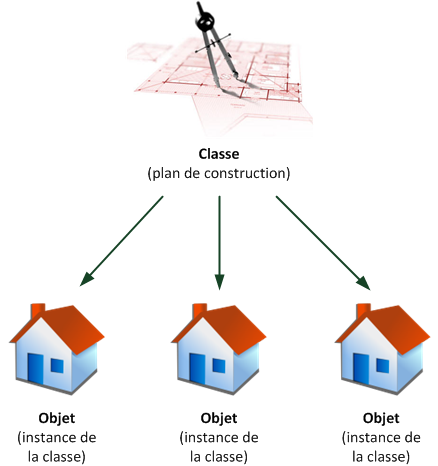    

On parle alors d'un objet en tant qu'**instance** d'une **classe** (création d'un objet ayant les propriétés de la classe).
    
    
***Remarque :*** Le nom des classes doit être écrit en camel case, et toujours en commençant par une majuscule, pour le différentier des fonctions, par exemple **`CompteBancaire`**.

In [1]:
# une classe vide
class Personnage:
    pass

# on peut tout de même s'en servir pour instancier des objets :
gollum = Personnage()
print(gollum)
gandalf = Personnage()
print(gandalf)
# ces objets sont des capsules mémoire indépendantes
# dans lesquelles ont peut stocker des données : attributs
gandalf.vie = 100
gollum.vie = 50
gandalf.force = 80
gollum.force = 60
print('Gollum :', gollum.vie, gollum.force)
print('Gandalf :', gandalf.vie, gandalf.force)

Gollum : 50 60
Gandalf : 100 80


<div class = "alert alert-block alert-info"> 
    
   
### Le constructeur  
    
On aimerait que notre objet se paramètre tout seul lors de son instanciation. Pour cela on utilise un constructeur.     
    
Le **constructeur** permet de configurer l'objet lors de son instanciation. Il s'agit d'une méthode Il doit respecter les contraintes suivantes :
    
- le nom de cette méthode doit être obligatoirement **`__init__`**;  
- cette méthode (comme toutes les méthodes !) doit accepter au moins un paramètre, une référence d’instance, dont le nom doit être **`self`**, et qui doit être le premier paramètre. **`self`** représente **l’identité de l’objet instancié**.
   
    

In [2]:
class Personnage:
    def __init__(self, force):
        self.vie = 100
        # force est un parametre qui disparaitra de la mémoire
        # une fois __init__ exécutée.
        # pour conserver cette valeur en mémoire, 
        # on doit créer un attribut d'instance.
        self.force = force

gollum = Personnage(60)
gandalf = Personnage(80)
print('Gollum :', gollum.vie, gollum.force)
print('Gandalf :', gandalf.vie, gandalf.force)

Gollum : 100 60
Gandalf : 100 80


<div class = "alert alert-block alert-info"> 
    
C’est bien ça mais ils ne font rien nos personnages ...

    
### Ajout d'une méthode 
    
Il pourrait reprendre des forces en mangeant par exemple :
    
Une classe est une fonction :
    
- déclarée dans la classe auquelle elle appartient;    
- qui doit accepter au moins un paramètre, une référence d’instance, dont le nom doit être **`self`**, et qui doit être le premier paramètre. **`self`** représente **l’identité de l’objet instancié**.
   
    

In [3]:
class Personnage:
    def __init__(self, vie, force):
        self.vie = vie
        self.force = force
        
    def manger(self):
        self.force += 1
        if self.vie < 100:
            self.vie += 1

gandalf = Personnage(99, 80)
print('Gandalf :', gandalf.vie, gandalf.force)
gandalf.manger()
print('Gandalf :', gandalf.vie, gandalf.force)
gandalf.manger()
print('Gandalf :', gandalf.vie, gandalf.force)

Gandalf : 99 80
Gandalf : 100 81
Gandalf : 100 82


??? question A vous de jouer ?

## Des chiens
    
On souhaite coder une classe Chien, qui permette d’instancier des objets représentant des chiens. Le constructeur de cette classe initialisera deux attributs d’instance nom et age.  
Trois méthodes seront définies :  
- **vieillir(nb_annee)** permettra de faire vieillir le chien d’un certain nombre d’année;  
- **age_humain()** qui renvoi l’age équivalent du chien en année humaine en multipliant son age réel par 7 ;  
- **info()** qui renvoi une chaine de la forme "Je m'apelle ..., j'ai ... ans"
    
    
Exemples d’utilisation de cette classe :
    
```python
>>> c1 = Chien('Médor', 2)
>>> c1.nom
'Médor'
>>> c1.age_humain()
14
>>> c1.viellir(2)
>>> c1.age
4
>>> c1.age_humain()
28
>>> c1.info()
"Je m'apelle Médor, j'ai 4 ans"    
``` 
    
Ecrivez la classe **`Chien`** et testez la. 
    
???

??? success Correction

```python
class Chien:
    def __init__(self, nom, age):
        self.nom = nom
        self.age = age
        
    def vieillir(self, nb_annee):
        if not isinstance(nb_annee, int) or nb_annee < 0:
            raise ValueError('Entrée incorrecte')
        self.age += nb_annee
        
    def age_humain(self):
        return self.age * 7
        
    def info(self):
        return f'{self.nom} : {self.age}ans'
```

???

!!! info La notation pointée  

Soit deux classes :
 
```python
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y
    
class Boite:
    def __init__(self, coin, w, h):
        self.coin = coin
        self.largeur = w
        self.hauteur = h
``` 
La classe **`Boite`** contient (on dit agrège) un objet de la classe **`Point`**.  
    
```python
>>> a = Point(12, 27)
>>> boite = Boite(a, 50, 35)
>>> boite.coin.x
12    
>>> boite.coin.y
27
```     
    
Notez la façon dont on peut accéder aux attributs de `coin` lui-même attributs de `boite`. Chaque instance constitue un **espace de nommage** clôt, c'est le principal interêt de l'encapsulation. La notation pointée permet d'accéder aux attributs et méthode dans un espace de nommage. 
    
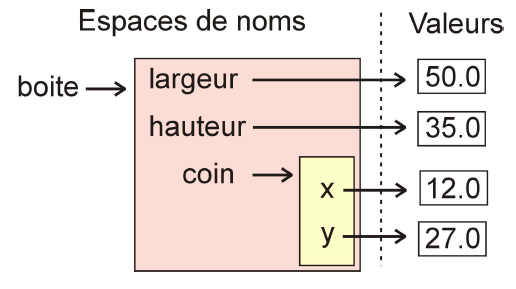   

!!!

<div class = "alert alert-block alert-info"> 
    
### L'abstraction  
    
L’abstraction consiste à afficher ou masquer les détails d’un objet à l’utilisateur (ou aux autres objets avec lequel il interagit) pour n’exposer que les éléments qui leur seront utiles.

#### public, privé, brouillé    
    
**Attributs** et **méthodes** peuvent être :
    
- **public** : Un utilisateur peut les lire directement via le nom de l'instance. **`gandalf.vie`** par exemple. En python ils peuvent même être modifiés (et même crées !), ces pratiques (généralement interdites par les langages très orientés objet comme JAVA) sont à éviter. 
- **privé** : On interdit symboliquement l'accés en faisant précédé leur noms par un underscore **`_`**. Ces méthodes et attributs ne font alors plus partie de **l'interface** de l'objet. 
- **brouillé** : on définit un attribut brouillé en faisant précédé son nom par un double underscore **`__`**. L'accès est alors plus compliqué mais toujours possible. Cela est peu utilisé en python.
    
#### Accesseurs et modificateurs
    
Les **accesseurs** (getter en anglais) et les **modificateurs** (setter en anglas) permettent de lire et modifier, sous condition certains attributs privés. Ce sont des **méthodes** dont le rôle est de :
- contrôler, masquer l'accès a certains attributs;
- interdire de mettre n'importe quoi dans un attribut.   
    
#### Dans le cadre de la NSI  
La notion d'interface (ce que l'on peut faire avec un objet) est au programme dans les types abstraits de donnée.  
Toutefois, il ne faut pas alourdir inutilement le code en mettant des accesseurs partout (comme on peut le voir en JAVA par exemple), cela rend les classes très lourdes et moins lisibles pour les élèves. A titre personnel, je laisse l'accès en lecture aux attributs depuis l'exterieur de l'objet par contre j'interdis de modifier et de créer un attributs hors de la classe.   
    

In [4]:
class Bidule:
    def __init__(self):
        self.pub = 5
        self._pri = 10
        self.__bro = 15
        
c = Bidule()
print(c.pub)
print(c._pri) # possible mais on ne doit pas le faire
print(c.__bro) # a priori impossible mais contournable

5
10


Traceback (most recent call last):
  File "<basthon-input-4-9b756fd61f85>", line 10, in <module>
    print(c.__bro) # a priori impossible mais contournable
          ^^^^^^^
AttributeError: 'Bidule' object has no attribute '__bro'


In [ ]:
class Personnage:
    def __init__(self, vie, force):
        # deux attributs privé : plus d'accès directe
        self._vie = 100
        self.set_vie(vie)
        self._force = force
        
    def manger(self):
        self._force += 1
        if self._vie < 100:
            self._vie += 1
    
    # un modificateur
    def set_vie(self, vie):
        if not isinstance(vie, int) or not 0 <= vie <= 100:
            raise ValueError('vie doit être un int compris entre 0 et 100.')
        self.vie = vie
        
    # un accesseur
    def get_vie(self):
        return self._vie
            

??? question A vous de jouer ?
    
## Des comptes bancaires
    
On souhaite créer une classe **`CompteBancaire`**, qui permette d’instancier des objets tels que compte1, compte2, etc.  

Le constructeur de cette classe initialisera trois attributs d’instance **`nom`**, **`autorisation_decouvert`** (par défaut à 0) et **`_solde`**. **`_solde`** est un attribut privé.     
Ces méthodes seront définies :  
    
- **`depot(somme)`** permettra d’ajouter une certaine somme au solde ;  
- **`retrait(somme)`** permettra de retirer une certaine somme du solde; Le découvert éventuel ne doit pas dépasser **`autorisation_decouvert`**. Renvoi **`True`** si le retrait est passé, **`False`** si il est refusé. 
- **`solde()`** : renvoi le solde (nombre).  
- **`info()`** qui renvoi une chaine de la forme 'Le solde du compte bancaire de M. Bidule est de 2150€.'. 
    
    
Exemples d’utilisation de cette classe :

    
```python
>>> c1 = CompteBancaire('Bidule', 2000)
>>> c1.depot(350)
>>> c1.retrait(200)
True
>>> c1.solde()    
2150
>>> c1.retrait(2500)
False
>>> print(c1.info())
'Le solde du compte bancaire de M. Bidule est de 2150€.'

```     
    

Ecrivez la classe **`CompteBancaire`** et testez la.   
???

??? success Correction

```python
class CompteBancaire:
    def __init__(self, nom, solde, autorisation_decouvert=0):
        self.nom = nom
        self._solde = solde
        self.autorisation_decouvert = autorisation_decouvert
        
    def retrait(self, somme):
        if self._solde - somme >= -self.autorisation_decouvert:
            self._solde -= somme
            return True
        return False
        
    def solde(self):
        return self._solde
    
    def depot(self, somme):
        self._solde += somme
        
    def info(self):
        return f'Le solde du compte bancaire de M. {self.nom} est de {self._solde}€.'
```

???

??? info Pour aller plus loin : Les diagrammes de classe

## Diagramme de classe

Ils offrent une représentation graphique des classes et de leurs intéractions :

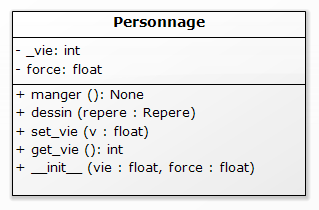

Il comporte 3 zones :  

- Le nom de la classe
- Les attributs
- Les méthodes

Il permet de définir graphiquement :
- le type de chaque attribut, paramètre, return
- définir ce qui est publique (signe +) ou privé (signe -)

***Remarque :*** hors programme de NSI.
???

??? info Pour aller plus loin : Les propriètés

## property  

Python intègre un mécanisme de setter et getter extrêmenent pratique : les propriètés. Il permet de manipuler un attribut privé comme s'il était publique, tout en contrôlant toutes les manipulations. 

```python
class Personnage:
    def __init__(self, nom, vie):
        self.nom = nom
        self._vie = vie

    @property
    def vie(self):
        return self._vie
    
    @vie.setter
    def vie(self, nouvelle_vie):
        if 0 < nouvelle_vie <= 100:
            self._vie = nouvelle_vie
```
l'attibut vie peut être affecté de manière transparente, comme s'il était publique :
```python
>>> p = Personnage('Gollum', 50)
>>> p.vie
50
>>> p.vie = 65
>>> p.vie
65
>>> p.vie = 125
>>> p.vie
65
```

Cela permet d'offrir plusieurs accesseurs et modificateurs pour un meme attribut, par exemple :

```python
class Chien:
    def __init__(self, nom, age):
        self.nom = nom
        self._age = age
        
    @property
    def age(self):
        return self._age
    
    @property
    def age_humain(self):
        return self._age * 7    
    
    @age.setter
    def age(self, a):
        if a > 0:
            self._age = a
        
    @age_chien.setter
    def age_humain(self, a):
        if a > 0:
            self._age = round(a / 7)    
```
C'est magique
```python
>>> c = Chien('Medor', 4)
>>> c.age
4
>>> c.age_humain
28
>>> c.age_humain = 35
>>> c.age
5
>>> c.age = 6
>>> c.age_humain
42
```

***Remarque :*** hors programme de NSI.
???

<div class = "alert alert-block alert-info"> 
    
### Intéraction entre objets   
    
Dans une approche objet, on va découper le programme en objet qui vont intéragir les uns avec les autres.  
    
Dans notre exemple, nos personnages pourraient recevoir des coups sur la tête.    
   
Ici, on va faire intéragir deux objet de la même classe dans une méthode. Dans la méthode **`prends_coup`**, il faut distinguer :
    
- **`self.vie`** : attribut **`vie`** de l'instance qui exécute la méthode **`prends_coup`**, ici gollum.
- **`perso.force`** : attribut **`force`** de l'instance **`perso`**, passée en argument, ici gandalf.    

In [6]:
from random import randint

class Personnage:
    def __init__(self, force):
        self.vie = 100
        self.force = force
        
    def prends_coup(self, perso):
        # perso est une instance de Personnage
        assert isinstance(perso, Personnage)
        dommage = randint(0, perso.force // 2)
        if self.vie > dommage:
            self.vie -= dommage
        else:
            self.vie = 0
        
    def est_mort(self):
        return self.vie == 0
        

In [7]:
gollum = Personnage(60)
gandalf = Personnage(80)

while not gollum.est_mort():
    gollum.prends_coup(gandalf)
    print('Gollum :', gollum.vie, gollum.est_mort())

Gollum : 68 False
Gollum : 46 False
Gollum : 38 False
Gollum : 2 False
Gollum : 0 True


??? info Pour aller plus loin : Les intéractions entre classes
    
### Les intéractions entre classe
    
Les intéractions entre classes sont bien formalisées en POO. Il en existe trois : l'association, l'agrégation, la composition, en fonction du niveau de dépendance des objets entre eux.    
    
#### Association  
    
Une association est une relation entre deux classes où un objet d’une classe utilise ou interagit avec un objet d’une autre classe, mais sans dépendance forte. Les objets peuvent exister indépendamment l’un de l’autre.    

Le fait pour une classe d'exécuter une méthode d'une autre classe est une association.
    
```python
class arme:
    def __init__(self, nom, dommage):
        self.type = nom
        self.dommage = dommage
    
class Personnage:
    def __init__(self, nom, force):
        self.nom = nom
        self.vie = 100
        self.force = force 
    
    def prends_coup(self, perso, arme):
        dommage = randint(0, (perso.force // 2) * arme.dommage)
        if self.vie > dommage:
            self.vie -= dommage
        else:
            self.vie = 0
        
a = Arme('Dard', 3)
p1 = Personnage('Gollum', 30)
p2 = Personnage('Frodon', 50)
    
p1.prends_coup(p1, a)
```     

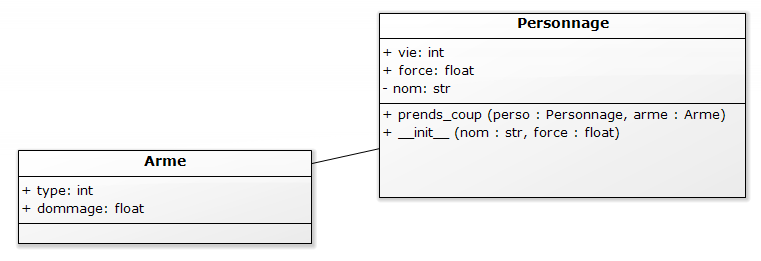

***Caractéristiques :***
- Relation faible, souvent temporaire.
- Pas de notion de possession.
    
    
#### Agrégation    

L’agrégation est une relation plus forte que l’association, où une classe (le tout) contient une référence à une autre classe (la partie), mais la partie peut exister sans le tout.
    
```python
class arme:
    def __init__(self, nom, dommage):
        self.type = nom
        self.dommage = dommage
    
class Personnage:
    def __init__(self, nom, force, arme):
        self.nom = nom
        self.vie = 100
        self.force = force   
        assert isinstance(arme, Arme), 'ValueError, arme doit être une instance de Arme'
        # Agrégation : Personnage possede une référence vers arme
        # mais arme existe sans Personnage 
        self.arme = arme
        
a = Arme('Dard', 3)
p2 = Personnage('Frodon', 50, a)
```

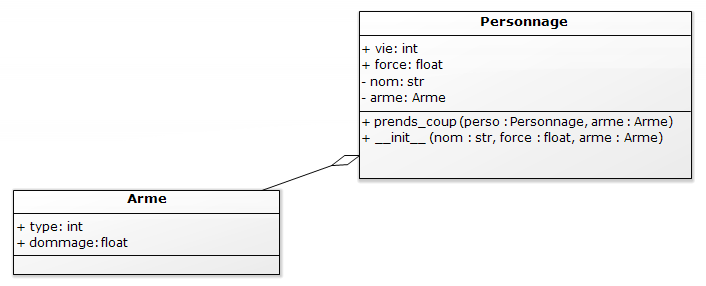

***Caractéristiques :***

- Relation de type 'possède'.
- La partie (arme) peut exister sans le tout (Personnage).
    
    
#### Composition    

La composition est une relation encore plus forte : la partie ne peut pas exister sans le tout. Si le tout est détruit, la partie l’est aussi.    
    
    
```python
class Voiture:
    def __init__(self):
        self.moteur = Moteur()  # Le moteur est créé avec la voiture

class Moteur:
    def __init__(self):
        pass

# Composition : une voiture a un moteur, et le moteur n'existe pas sans la voiture.
ma_voiture = Voiture()    
```    

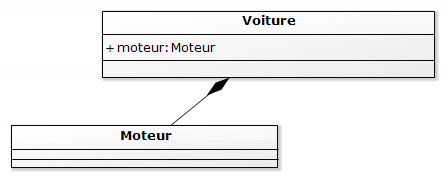

***Caractéristiques :***

- Relation de type 'est composé de'.
- La partie (moteur) est créée et détruite avec le tout (voiture).
???    

??? question A vous de jouer ?
    
## Des comptes bancaires

Une personne peut avoir plusieurs comptes bancaires. Revoyons notre modèle avec deux classes :   

#### Classe **`Personne`**  

Le constructeur de cette classe initialisera trois attributs d’instance **`nom`**, **`date_naissance`** et **`comptes_bancaires`** qui est une liste vide.  
Ces méthodes seront définies :  
    
- **`ajouter_compte(compte: CompteBancaire)`** permettra d’ajouter un compte à la liste des comptes ;  
- **`solde()`** : renvoi le solde (nombre) total de l'ensemble des comptes bancaires.  
- **`info()`** qui renvoi une chaine de la forme 'M. Bidule 09/12/1995, 3 comptes'.

#### Classe **`CompteBancaire`**

Cette classe est presque identique a celle définie dans l'exercice précédent mais :
- L'attribut d’instance **`nom`** correspond maintenant au nom du compte : 'Livret A' par exemple.  
- **`info()`** qui renvoi une chaine de la forme "Le solde du compte 'Livret A' est de 2150€.". 
    
    
Exemples d’utilisation de cette classe :

    
```python
>>> p = Personne('Bidule', '09/12/1995')
>>> p.info()
'M. Bidule 09/12/1995, 0 comptes'
>>> p.ajouter_compte(CompteBancaire('Livret A', 2000))
>>> p.ajouter_compte(CompteBancaire('Courant', 1000))
>>> p.info()
'M. Bidule 09/12/1995, 2 comptes'
>>> p.solde()
3000
```     

Ecrivez la classe **`Personne`**, modifiez la classe **`comptes_bancaires`** et testez les.  De quels interactions s'agit-il ? 
???

In [ ]:
class CompteBancaire:
    def __init__(self, nom, solde, autorisation_decouvert=0):
        self.nom = nom
        self._solde = solde
        self.autorisation_decouvert = autorisation_decouvert
        
    def retrait(self, somme):
        if self._solde - somme >= -self.autorisation_decouvert:
            self._solde -= somme
            return True
        return False
        
    def solde(self):
        return self._solde
    
    def depot(self, somme):
        self._solde += somme
        
    def info(self):
        return f'Le solde du compte {self.nom} est de {self._solde}€.'
    
class Personne:
    def __init__(self, nom, date_naissance):
        

??? success Correction

```python
class CompteBancaire:
    def __init__(self, nom, solde, autorisation_decouvert=0):
        self.nom = nom
        self._solde = solde
        self.autorisation_decouvert = autorisation_decouvert
        
    def retrait(self, somme):
        if self._solde - somme >= -self.autorisation_decouvert:
            self._solde -= somme
            return True
        return False
        
    def solde(self):
        return self._solde
    
    def depot(self, somme):
        self._solde += somme
        
    def info(self):
        return f'Le solde du compte {self.nom} est de {self._solde}€.'
    
class Personne:
    def __init__(self, nom, date_naissance):
        self.nom = nom
        self.date_naissance = date_naissance
        self.comptes_bancaires = []
        
    def ajoute_compte(self, c):
        assert isinstance(c, CompteBancaire)
        self.comptes_bancaires.append(c)
        
    def solde(self):
        somme = 0
        for c in self.comptes_bancaires:
            somme += c.solde()
        return somme
    
    def info(self):
        return f'{self.nom} {date_naissance}, {len(self.comptes_bancaires)} comptes.'        
```

Il s'agit d'une **agrégation**.

???

<div class = "alert alert-block alert-info"> 
    
### Le polymorphisme 
    
Le polymorphisme permet a certaines fonctions de s'adapter automatiquement aux objets qu'elle reçoit en argument. Par exemple l'instruction **print** est toujours capable d'afficher quelque chose. 

```python
>>> a = 'Coucou'
>>> print(a)
Coucou    
>>> b = [1, 2, 3, 4]
>>> print(b)
[1, 2, 3, 4]    
>>> gollum = Personnage(60)
>>> print(gollum) 
<__main__.Personnage object at 0x1273548>    
```    
Ma classe sait déjà faire des choses que je ne lui ai pas apprise … Le `print` appliqué a mon objet m’affiche quelque chose même si ce n’est pas très clair …   
    
Le fait que ma classe soit capable de donner quelque chose a afficher a l’instruction `print` est dû au fait qu’elle a hérité de la classe object. Classe parente de tous les objets en python :
    
- toutes les classes possède déja une **méthode magique** appellée **`__repr__`** qui fournit une repésentation sous forme **`str`** aux instructions qui lui demande. 
- On peut redéfinir cette méthode si on le souhaite pour fournir une vue claire de notre objet.    

#### Méthodes magiques  
Il existe de nombreuses méthodes magiques, citons :
- **`__repr__`** : affichage en console ou dans une liste par exemple. Doit renvoyée une chaine riche en info.   
- **`__len__`** : instruction **`len`**
- **`__str__`** : si non définit, **print** utilise **`__repr__`**. Doit renvoyer une chaine lisible.     
- **`__add__`** : opérateur addition **`+`**    
- **`__sub__`** : opérateur **`-`**  
- **`__div__`** : opérateur **`/`**
- **`__mul__`** : opérateur **`*`**
- **`__eq__`** : test d'agalité, opérateur **`==`**
- **`__getitem__`** : Cette méthode est utilisée pour accéder à un élément spécifique de l'objet à l'aide de la notation des crochets ([]).   
- ...    
    
Pour plus d'info et d'exemple : 
    https://geekflare.com/fr/magic-methods-in-python/
    https://www.tresfacile.net/les-methodes-magiques-en-poo-python/
    
***Remarque :*** Le polymorphisme n'est pas au programme de terminale mais certains aspects très simplifié peuvent être montré aux élèves. Je me limite personnellement a **`__repr__`** et **`__len__`** .  
    

In [25]:
a = 'Coucou'
print(a)
b = [1, 2, 3, 4]
print(b)
gollum = Personnage(60)
print(gollum)

Coucou
[1, 2, 3, 4]


Traceback (most recent call last):
  File "<basthon-input-25-eea1b93e71c1>", line 5, in <module>
    gollum = Personnage(60)
             ^^^^^^^^^^^^^^
TypeError: Personnage.__init__() missing 2 required positional arguments: 'vie' and 'force'


In [24]:
class Personnage:
    def __init__(self, nom, vie, force):
        self.nom = nom
        self.vie = vie
        self.force = force
        
    def __repr__(self):
        return f"{self.nom}, {self.vie} pts de vie et {self.force} pts de force."

In [27]:
p1 = Personnage('Gandalf', 100, 80)
print(p1)

Gandalf, 100 pts de vie et 80 pts de force.


??? question A vous de jouer ?
    
## Des comptes bancaires

Ajoutons un peu de polymorphisme ...

#### Classe **`Personne`**  
 
Ce qui change :  

- **`__getitem__`** : renvoi le compte d'index **`i`** en utilisant la notation crochet **`...[i]`**  
- **`info`** devient **`__repr__`** qui renvoi une chaine de la forme 'M. Bidule 09/12/1995, 3 comptes'.
- **`__len__`** renvoi le nombre de comptes bancaires

#### Classe **`CompteBancaire`**

Ce qui change :  

- **`info`** devient **`__repr__`**
    
Exemples d’utilisation de ces classes :
    
```python
>>> p = Personne('Bidule', '09/12/1995')
>>> p.ajoute_compte(CompteBancaire('Livret A', 2000))
>>> p.ajoute_compte(CompteBancaire('Courant', 1000))
>>> p
'M. Bidule 09/12/1995, 2 comptes'
>>> len(p)
2
>>> p.solde()
3000
>>> p[0].depot(500)
>>> p[1].retrait(100)
>>> p[0].solde
2500
>>> p[1].solde
900
>>> p.solde()
3400
```     

Ecrivez la classe **`Personne`**, modifiez la classe **`comptes_bancaires`** et testez les.  De quels interactions s'agit-il ? 
???

??? success Correction

```python
class CompteBancaire:
    def __init__(self, nom, solde, autorisation_decouvert=0):
        self.nom = nom
        self._solde = solde
        self.autorisation_decouvert = autorisation_decouvert
        
    def retrait(self, somme):
        if self._solde - somme >= -self.autorisation_decouvert:
            self._solde -= somme
            return True
        return False
        
    def solde(self):
        return self._solde
    
    def depot(self, somme):
        self._solde += somme
        
    def __repr__(self):
        return f'Le solde du compte {self.nom} est de {self._solde}€.'
    
class Personne:
    def __init__(self, nom, date_naissance):
        self.nom = nom
        self.date_naissance = date_naissance
        self.comptes_bancaires = []
        
    def ajoute_compte(self, c):
        assert isinstance(c, CompteBancaire)
        self.comptes_bancaires.append(c)      
        
    def solde(self):
        somme = 0
        for c in self.comptes_bancaires:
            somme += c.solde()
        return somme
    
    def __getitem__(self, i):
        return self.comptes_bancaires[i]
    
    def __repr__(self):
        return f'{self.nom} {date_naissance}, {len(self)} comptes.'  
    
    def __len__(self):
        return len(self.comptes_bancaires)     
```

???

??? info Pour aller plus loin : Les itérables
    
### Rendre une classe itérable  

En python, cela repose sur deux méthodes magiques : **`__iter__`** et **`__next__`**.

#### Une classe itérable

Pour créer un objet itérable, il faut qu'il réponde a l'instruction **`__iter__`**. Pour cela, il doit posséder une méthode **`__iter__`** qui renvoie un itérateur.  

#### Itérateur  

Un itérateur est un objet qui répond a l'instruction **`next`** en renvoyant la valeur suivante, puis une exception **`StopIteration`** quand il n'y a plus de donnée disponible. Pour cela, la classe doit contenir une méthode **`__next__`**.

### Solution a une seule classe

La même classe peut être utilisée pour contenir **`__iter__`** et **`__next__`**, avec quelques limitations.  
***Exemple :*** Un objet qui génère les lettres de l'alphabet.

La même classe étant utilisée comme itérable et itérateur, la méthode **`__iter__`** renvoi **`self`**, c'est à dire l'instance elle-même, qui va servir également d'itérateur.
    
```python
class Alphabet:
    def __init__(self):
        self.i = 0
        
    def __iter__(self):
        self.i = 0
        # la même classe servant d'itérateur
        # cette méthode renvoie l'instance elle-même
        return self
    
    def __next__(self):
        if self.i < 26:
            self.i += 1
            return chr(64 + self.i)
        raise StopIteration
```     
Exemple d'utilisation 'manuelle' :
    
```python
>>> alpha = Alphabet(maj=True)
>>> it = iter(alpha)
>>> for i in range(26):
        print(next(it), end='')
ABCDEFGHIJKLMNOPQRSTUVWXYZ
>>> next(it)
'StopIteration'
```

ou avec une boucle for :
```python
>>> for u in alpha:
        print(u, end='')
ABCDEFGHIJKLMNOPQRSTUVWXYZ
```
Mais on ne peut pas créer plusieurs itérateurs indépendants :

```python
>>> alpha = Alphabet()
>>> it1 = iter(alpha)
>>> it2 = iter(alpha)
>>> for i in range(13):
        print(next(it1), end='')
ABCDEFGHIJKLM
>>> for i in range(13):
        print(next(it2), end='')
NOPQRSTUVWXYZ
```
idem avec des boucles for, on n'obtiens pas le résultat excompté :
```python
>>> for u in alpha:
        print(u, '->', end='')
        for y in alpha:
            print(y, end='')
        print()
A ->ABCDEFGHIJKLMNOPQRSTUVWXYZ        
```
    
### Solution a deux classes

Si on veut supprimer les limitations précédentes, il faut séparer la classe qui génère l'itérateur :
    
```python
class Iterateur:
    def __init__(self):
        self.i = 0
        
    def __next__(self):
        if self.i < 26:
            self.i += 1
            return chr(64 + self.i)
        raise StopIteration

class Alphabet:
    def __iter__(self):
        return Iterateur()
```  
 
Ou en imbricant les classes :   
    
```python
class Alphabet:
    class Iterateur:
        def __init__(self):
            self.i = 0
            
        def __next__(self):
            if self.i < 26:
                self.i += 1
                return chr(64 + self.i)
            raise StopIteration
        
    def __iter__(self):
        return Alphabet.Iterateur()  
```    
Résultats :

```python
>>> alpha = Alphabet()
>>> it1 = iter(alpha)
>>> it2 = iter(alpha)
>>> for i in range(13):
        print(next(it1), end='')
ABCDEFGHIJKLM
>>> for i in range(13):
        print(next(it2), end='')
ABCDEFGHIJKLM
```
idem avec des boucles for, on obtiens bien le résultat excompté :
```python
>>> for u in alpha:
        print(u, '->', end='')
        for y in alpha:
            print(y, end='')
        print()
A ->ABCDEFGHIJKLMNOPQRSTUVWXYZ
B ->ABCDEFGHIJKLMNOPQRSTUVWXYZ
C ->ABCDEFGHIJKLMNOPQRSTUVWXYZ
...
X ->ABCDEFGHIJKLMNOPQRSTUVWXYZ
Y ->ABCDEFGHIJKLMNOPQRSTUVWXYZ
Z ->ABCDEFGHIJKLMNOPQRSTUVWXYZ        
```
???    

<div class = "alert alert-block alert-info"> 
    
### L'héritage
    
L'héritage est l'un des piliers fondamentaux de la programmation orientée objet qui permet à une classe (appelée classe enfant) de dériver des attributs et des méthodes d'une autre classe (appelée classe mère). 
    
#### Interêt  
    
L'héritage est l'un des piliers fondamentaux de la programmation orientée objet. Il permet de créer une nouvelle classe  qui hérite de tous les attributs et de toutes les méthodes de la classe parente. L'héritage permet de construire une classe en partant d'une autre classe comme point de départ.
    
#### Surcharge d'un attribut    
    
    
Pour changer la valeur d'un attribut de la classe, rien de plus simple, il suffit de le redéclarer dans la classe enfant. 
    
#### Surcharge d'une méthode   
    
Comme pour un attribut, il suffit de la redéclarer.    
    
***Exemple :*** Un magicien est personnage un peu particulier : il possède des points de magie mais seulement 80 points vie. La Classe Magicien peut donc hériter de la classe Personnage :
    
```python
class Magicien(Personnage):
    def __init__(self, nom, force, magie):
        # Appel du constructeur de la classe parente
        # création des attributs vie, force, nom
        Personnage.__init__(self, nom, force)
        # surcharge de l'attribut vie
        self.vie = 80
        self.magie = magie
        
    def __repr__(self):
        # Nouvelle version de la méthode __repr__
        return Personnage.__repr__(self) + f", {self.magie} pts de magie."
```    
Sans rien faire de plus, notre magicien possède les méthodes : **`prends_coup`**, **`est_mort`**.
   
***Remarque :*** L'héritage n'est pas au programme de terminale.     

In [18]:
class Personnage:
    def __init__(self, nom, force):
        self.nom = nom
        self.vie = 100
        self.force = force
        
    def prends_coup(self, perso):
        # perso est une instance de Personnage
        assert isinstance(perso, Personnage)
        dommage = randint(0, perso.force // 2)
        if self.vie > dommage:
            self.vie -= dommage
        else:
            self.vie = 0
        
    def est_mort(self):
        return self.vie == 0        
        
    def __repr__(self):
        return f"{self.nom}, {self.vie} pts de vie, {self.force} pts de force"

In [19]:
# Un magicien est un personnage avec 80 points de vie et des points de magie
class Magicien(Personnage):
    def __init__(self, nom, force, magie):
        # Appel du constructeur de la classe parente
        # création des attributs vie, force, nom
        Personnage.__init__(self, nom, force)
        # surcharge de l'attribut vie
        self.vie = 80
        self.magie = magie
        
    def __repr__(self):
        # Nouvelle version de la méthode __repr__
        return Personnage.__repr__(self) + f", {self.magie} pts de magie."

In [20]:
p = Magicien('Gandalf', 85, 50)
print(p)
p.est_mort()

Gandalf, 80 pts de vie, 85 pts de force, 50 pts de magie.


False

!!! info super()
**`super()`** est une référence implicite a la classe parente. l'utilisation de **`super()`** permet de ne pas renommer la classe parente et de se passer du `self` lors de l'appel.

    
```python
class Magicien(Personnage):
    def __init__(self, nom, force, magie):
        super().__init__(nom, force)
        # surcharge de l'attribut vie
        self.vie = 80
        self.magie = magie
        
    def __repr__(self):
        return super().__repr__() + f", {self.magie} pts de magie."
```
**`super()`** permet églement de gérer les héritages multiples, que nous n'aborderons pas ici. Pour plus d'info sur ce point, vous pouvez consulter : https://deusyss.developpez.com/tutoriels/Python/heritage_metaclasse/
!!!

In [ ]:
class Magicien(Personnage):
    def __init__(self, nom, force, magie):
        super().__init__(nom, force)
        # surcharge de l'attribut vie
        self.vie = 80
        self.magie = magie
        
    def __repr__(self):
        # Nouvelle version de la méthode __repr__
        return super().__repr__() + f", {self.magie} pts de magie."
    
p = Magicien('Gandalf', 85, 50)
print(p)
p.est_mort()

??? info Pour aller plus loin : Héritage et diagrammes de classe

L'héritage est représenté comme cela dans un diagramme de classe :

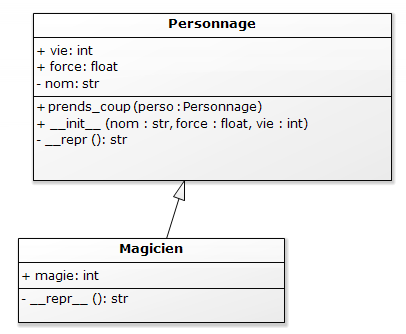

***Remarque :*** hors programme de NSI.
???

<div class = "alert alert-block alert-info"> 
    
### Les attributs et méthodes de classe  
    
On peut également définir des attributs commun a tous les objets d'une classe. Cela permet de définir des constantes par exemple.
    
#### Méthode de classe  
    
Une méthode de classe est identifiée par le décorateur **`@classmethod`** et prends comme premier parametre **`cls`**, a la place de **`self`**. Ce type de méthode accède au attributs de classe. Il est toujours possible de faire référence a un attribut de classe en utilisant le nom de la classe.    
    
#### syntaxe
    
```python
class Personnage:
    # constante de classe
    VIE_MAX = 100
    # attribut de classe
    population = 0
    
    def __init__(self, nom, force):
        self.nom = nom
        self.vie = Personnage.VIE_MAX
        self.force = force
        Personnage.population += 1
        
    @classmethod
    def get_population(cls):
        return cls.population
```    
    
    
    
Un tel attributs doit être affecter au début de la classe, avant le constructeur.    

In [ ]:
class Personnage:
    VIE_MAX = 100
    population = 0
    
    def __init__(self, nom, force):
        self.nom = nom
        self.vie = Personnage.VIE_MAX
        self.force = force
        Personnage.population += 1
        # pour numéroter chaque personnage
        self.num = Personnage.population
        
    @classmethod
    def get_population(cls):
        return cls.population
        
    def __repr__(self):
        return f"{self.nom}, N°{self.num}, {self.vie} pts de vie, {self.force} pts de force"        
        
p1 = Personnage('Gollum', 50)
p2 = Personnage('Gandalf', 50)
p3 = Personnage('Frodon', 50)
print(p2, '. Population totale :', p2.get_population())
print(p1, '. Population totale :', Personnage.population)
print(p3, '. Population totale :', p3.get_population())

<div class = "alert alert-block alert-info"> 
    
### Les méthodes statiques  
    
Les méthodes statiques peuvent être appelées directement par le nom de la classe, sans qu’il soit nécessaire de créer une instance de la classe. Il s'agit en quelque sorte d'une fonction, intégré a la classe. L’utilisation de **`@staticmethod`** en Python offre une possibilité ciblée d’organiser des fonctions au sein de classes qui n’ont pas besoin d’accéder à des données d’instance. Comme elles ne sont pas liées à une instance, elles ne peuvent pas modifier l’état d’un objet.     
  
    
#### syntaxe
    
```python
class Personnage:
    def __init__(self, nom, force):
        self.nom = nom
        self.vie = 80 + self.lancer_de(20)
        self.force = force
        
    @staticmethod
    def lancer_de(n_face):
        return randint(1, n_face)
```    
   

In [ ]:
from random import randint

class Personnage:
    def __init__(self, nom, force):
        self.nom = nom
        self.vie = 80 + self.lancer_de(20)
        self.force = force
        
    @staticmethod
    def lancer_de(n_face):
        return randint(1, n_face)
    
    def __repr__(self):
        return f"{self.nom}, {self.vie} pts de vie, {self.force} pts de force"    

In [ ]:
# on peut exécuter une méthode statique sans créer d'instance
Personnage.lancer_de(20)

In [ ]:
p = Personnage('Gandalf', 80)
p